In [ ]:
# Useful for installing packages with proper linking
import sys
# !{sys.executable} -m pip install numpy
import matplotlib.pyplot as plt # Useful for visualization
import seaborn as sns # Useful for visualization, it's built using matplotlib and is higher-level
import pandas as pd 
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
import time


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import MolsToGridImage # For displayinh multiple molecules
from rdkit.Chem.Draw import IPythonConsole # displays molecules in line
from rdkit.Chem import Descriptors
from rdkit.Chem.rdMolDescriptors import *
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys, AtomPairs, rdFingerprintGenerator
from rdkit.Chem import PandasTools
from rdkit import DataStructs
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np
from numpy import prod
import pandas as pd
from mordred import Calculator, descriptors
import matplotlib.pyplot as plt
from rdkit.Chem import AddHs
from rdkit.Chem.rdmolops import PatternFingerprint
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem.AtomPairs.Pairs import GetAtomPairFingerprintAsBitVect
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

In [4]:
data = pd.read_csv('delaney.csv')
data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl


In [6]:
# Let's first take the SMILES column and generate our descriptors

mol_list = []

for smile in data['SMILES']:
    mol = Chem.MolFromSmiles(smile)  # generating molecule objects
    mol = Chem.AddHs(mol)           # adding hydrogens
    AllChem.EmbedMolecule(mol)  # generating 3D geometries from these molecular objects
    mol_list.append(mol)

data = pd.concat([data, pd.DataFrame(mol_list, columns = (['Mol']))], axis=1)

In [7]:
data.head()

,Compound ID,measured log(solubility:mol/L),ESOL predicted log(solubility:mol/L),SMILES,Mol
0,"1,1,1,2-Tetrachloroethane",-2.18,-2.794,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001DB1FC...
1,"1,1,1-Trichloroethane",-2.00,-2.232,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001DB1FC...
2,"1,1,2,2-Tetrachloroethane",-1.74,-2.549,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001DB1FC...
3,"1,1,2-Trichloroethane",-1.48,-1.961,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001DB1FC...
4,"1,1,2-Trichlorotrifluoroethane",-3.04,-3.077,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x000001DB1FC...


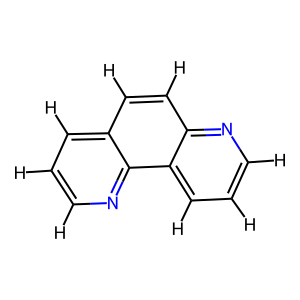

In [10]:
# Let's visualize a molecule
mol = data['Mol'][54]

img = Draw.MolToImage(mol)
img

In [25]:
pip install numpy==1.23.5 # Downgrading the NumPy to prevent 'module 'numpy' has no attribute 'float'' error

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 1.23.5 which is incompatible.



   ---------------------------------------- 0.0/14.6 MB ? eta -:--:--
   ----- ---------------------------------- 2.1/14.6 MB 13.0 MB/s eta 0:00:01
   ----------------- ---------------------- 6.6/14.6 MB 17.5 MB/s eta 0:00:01
   -------------------------------- ------- 12.1/14.6 MB 20.4 MB/s eta 0:00:01
   ---------------------------------------  14.4/14.6 MB 20.6 MB/s eta 0:00:01
   ---------------------------------------- 14.6/14.6 MB 17.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4


In [27]:
# To create descriptors list, we are first creating an instance of the calculator class and since we want both 2D and 3D descriptors, using ignore_3D=False
# generating a descriptor calculator
data = pd.read_csv('delaney.csv')
mol_list = []

for smile in data['SMILES']:
    mol = Chem.MolFromSmiles(smile)  # generating molecule objects
    mol = Chem.AddHs(mol)           # adding hydrogens
    AllChem.EmbedMolecule(mol)  # generating 3D geometries from these molecular objects
    mol_list.append(mol)

data = pd.concat([data, pd.DataFrame(mol_list, columns = (['Mol']))], axis=1)

calc = Calculator(descriptors, ignore_3D=False)
all_desc = calc.pandas(data['Mol'])
all_desc.head()

100%|██████████████████████████████████████████████████████████████████████████████| 1144/1144 [00:56<00:00, 20.25it/s]


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,4.012290,4.284816,0,0,5.818626,2.074313,4.148627,5.818626,0.969771,2.626363,...,7.989899,31.665095,165.891061,20.736383,28,3,24.0,22.0,4.3125,1.375000
1,3.464102,3.464102,0,0,4.000000,2.000000,4.000000,4.000000,0.800000,2.444466,...,7.625107,29.418928,131.930033,16.491254,16,0,20.0,16.0,4.0625,1.000000
2,3.932653,4.244375,0,0,6.000000,2.000000,4.000000,6.000000,1.000000,2.610845,...,7.626083,30.698690,165.891061,20.736383,29,4,22.0,21.0,4.222222,1.444444
3,3.047207,3.305183,0,0,5.226252,1.847759,3.695518,5.226252,1.045250,2.408576,...,6.834109,27.254130,131.930033,16.491254,18,2,16.0,14.0,3.361111,1.333333
4,5.808525,6.167293,0,0,7.211103,2.302776,4.605551,7.211103,0.901388,2.947233,...,9.037771,36.999431,185.901768,23.237721,58,9,38.0,40.0,6.125,1.562500


In [76]:
%pwd

'C:\\Users\\Rajwinder\\Downloads'

In [22]:
all_desc.shape  # we have 1144 molecules and 1826: 2D and 3D des

(1144, 1826)

In [28]:
# Let's grab the important columns from our dataset like UD, solubility, SMILES and add them to our descriptors DF

df_index = data[['Compound ID', 'SMILES', 'measured log(solubility:mol/L)']]
df = pd.concat([df_index, all_desc], axis=1)
df.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.18,4.012290,4.284816,0,0,5.818626,2.074313,4.148627,...,7.989899,31.665095,165.891061,20.736383,28,3,24.0,22.0,4.3125,1.375000
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.00,3.464102,3.464102,0,0,4.000000,2.000000,4.000000,...,7.625107,29.418928,131.930033,16.491254,16,0,20.0,16.0,4.0625,1.000000
2,"1,1,2,2-Tetrachloroethane",ClC(Cl)C(Cl)Cl,-1.74,3.932653,4.244375,0,0,6.000000,2.000000,4.000000,...,7.626083,30.698690,165.891061,20.736383,29,4,22.0,21.0,4.222222,1.444444
3,"1,1,2-Trichloroethane",ClCC(Cl)Cl,-1.48,3.047207,3.305183,0,0,5.226252,1.847759,3.695518,...,6.834109,27.254130,131.930033,16.491254,18,2,16.0,14.0,3.361111,1.333333
4,"1,1,2-Trichlorotrifluoroethane",FC(F)(Cl)C(F)(Cl)Cl,-3.04,5.808525,6.167293,0,0,7.211103,2.302776,4.605551,...,9.037771,36.999431,185.901768,23.237721,58,9,38.0,40.0,6.125,1.562500


In [29]:
# Let's dave the dataset in excel

df.to_excel('delaney_mordred.xlsx', index=None)

In [30]:
# Data Preprocessing:
# Remove missing/non-numerical values, remove constant values, remove highly correlated values
# Before making any changes, let's save a new dataset with name 'data' we're grabbing all the columns including and after column 3

data = df.iloc[:, 3:]
data.head()

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,4.012290,4.284816,0,0,5.818626,2.074313,4.148627,5.818626,0.969771,2.626363,...,7.989899,31.665095,165.891061,20.736383,28,3,24.0,22.0,4.3125,1.375000
1,3.464102,3.464102,0,0,4.000000,2.000000,4.000000,4.000000,0.800000,2.444466,...,7.625107,29.418928,131.930033,16.491254,16,0,20.0,16.0,4.0625,1.000000
2,3.932653,4.244375,0,0,6.000000,2.000000,4.000000,6.000000,1.000000,2.610845,...,7.626083,30.698690,165.891061,20.736383,29,4,22.0,21.0,4.222222,1.444444
3,3.047207,3.305183,0,0,5.226252,1.847759,3.695518,5.226252,1.045250,2.408576,...,6.834109,27.254130,131.930033,16.491254,18,2,16.0,14.0,3.361111,1.333333
4,5.808525,6.167293,0,0,7.211103,2.302776,4.605551,7.211103,0.901388,2.947233,...,9.037771,36.999431,185.901768,23.237721,58,9,38.0,40.0,6.125,1.562500


In [31]:
# Removing missing values
data.isnull()  # If it is true, means there is a null value

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1140,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1141,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1142,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [32]:
# Since dataset is too big, let's sum all the null values
data.isnull().sum()

ABC         0
ABCGG       0
nAcid       0
nBase       0
SpAbs_A     0
           ..
WPol        0
Zagreb1     0
Zagreb2     0
mZagreb1    0
mZagreb2    0
Length: 1826, dtype: int64

In [33]:
# Additionally, since there are too many descriptors, instead of looking at every single one, let's just sum the values to see of any exists
data.isnull().sum().sum()


0

In [35]:
# Let's look for non-numeric values/strings/errors
# I want a list of the column names with these only numeric values and the ones with Boolean values
# running a for loop: screen through each column in the column names of the dataset, if the datatype is object, it would just skip over
# objects basically are string values that we don't want here
# if the value is boolean, it would be stored in our Boolean list
# if the value is numeric, it would be stored in the other list

column_num = []
column_bool = []
for column in data.columns:
    column_type = data[column].dtype
    if column_type == 'object':
        pass
    elif column_type == 'bool':
        column_bool.append(column)
    else:
        column_num.append(column)


In [36]:
len(column_bool)

2

In [37]:
len(column_num)

1271

In [38]:
column_bool

['Lipinski', 'GhoseFilter']

In [39]:
# Let's check how these 2 columns look like:

data['Lipinski']

0       True
1       True
2       True
3       True
4       True
        ... 
1139    True
1140    True
1141    True
1142    True
1143    True
Name: Lipinski, Length: 1144, dtype: bool

In [40]:
# If we just want the unique values and remove duplicates

data['Lipinski'].unique()

array([ True, False])

In [41]:
data['GhoseFilter'].unique()

array([False,  True])

<Axes: xlabel='Lipinski'>

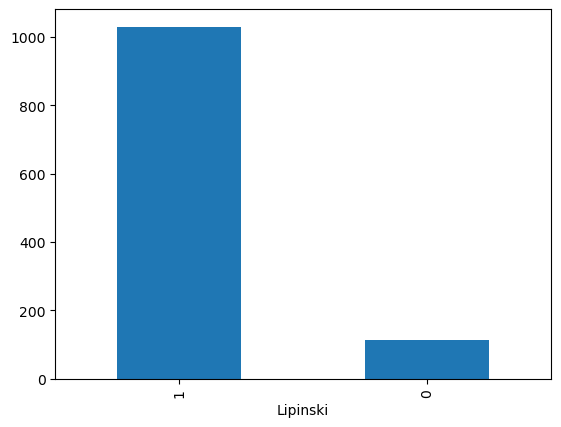

In [43]:
# Let's convert these TRUE and FALSE values into 0 and 1
# then plotting the barplot to see how many molecules have T or F values
lipsinki = data['Lipinski'].astype(int)
lipsinki.value_counts().plot(kind='bar')
# More than 1000 values with value 1 

<Axes: xlabel='GhoseFilter'>

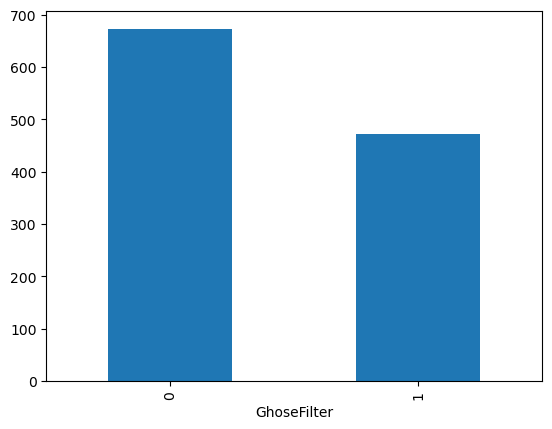

In [44]:
ghoseFilter = data['GhoseFilter'].astype(int)
ghoseFilter.value_counts().plot(kind='bar')
# lot more FALSE values (650) than TRUE values (450)

In [47]:
# Let's slice the dataset based on these columns, now we have all the descriptors (including Boolean ones)

data = data[column_num + column_bool]
data.shape

# In the beginning, we had more than 1800 descriptors, but they got truncated by getting rid of non-numeric values

(1144, 1273)

In [59]:
# Let's get rid of the constant values

def remove_constant_values(data):
    return [e for e in df.columns if df[e].nunique() == 1]  # df is the dataset with the original 3 columns included 

drop_col = remove_constant_values(data)

new_df_columns = [e for e in data.columns if e not in drop_col] # data is the dataset with only descriptor columns but missing/non-numeric issue resolved
# What's happening: we are sort of making a reference sheet (drop_col) that meets the first condition of having only constant (1 unique) values
# Then we're seeing if any columns in the newly altered descriptors dataset matches the reference sheet, if yes
# we're making a new list/dataset with those columns dropped
new_df = df[new_df_columns]
new_df

# now we only have 1120 columns

,ABC,ABCGG,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,VE1_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,Lipinski,GhoseFilter
0,4.012290,4.284816,0,5.818626,2.074313,4.148627,5.818626,0.969771,2.626363,2.285500,...,31.665095,165.891061,20.736383,28,3,24.0,22.0,1.375000,True,False
1,3.464102,3.464102,0,4.000000,2.000000,4.000000,4.000000,0.800000,2.444466,2.121320,...,29.418928,131.930033,16.491254,16,0,20.0,16.0,1.000000,True,False
2,3.932653,4.244375,0,6.000000,2.000000,4.000000,6.000000,1.000000,2.610845,2.309401,...,30.698690,165.891061,20.736383,29,4,22.0,21.0,1.444444,True,False
3,3.047207,3.305183,0,5.226252,1.847759,3.695518,5.226252,1.045250,2.408576,2.130986,...,27.254130,131.930033,16.491254,18,2,16.0,14.0,1.333333,True,False
4,5.808525,6.167293,0,7.211103,2.302776,4.605551,7.211103,0.901388,2.947233,2.602595,...,36.999431,185.901768,23.237721,58,9,38.0,40.0,1.562500,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,10.943860,10.834541,0,19.178732,2.222674,4.445348,19.178732,1.198671,3.613477,3.333258,...,46.989352,287.041487,8.442397,532,20,68.0,73.0,3.986111,True,True
1140,13.848577,12.817957,0,21.491177,2.513161,4.873236,21.491177,1.193954,3.821470,3.668785,...,66.116663,284.995949,10.555406,559,30,96.0,115.0,3.916667,True,True
1141,17.872588,14.857897,0,29.447228,2.482065,4.964130,29.447228,1.280314,4.064996,4.121171,...,57.517610,308.104859,7.900125,1092,38,120.0,142.0,5.083333,True,True
1142,17.730457,15.492423,0,27.142711,2.437677,4.875353,27.142711,1.180118,4.049881,4.179173,...,57.566543,354.044106,9.316950,1172,38,120.0,140.0,4.888889,True,True


In [49]:
# How many descriptors did we drop

len (drop_col)

153

In [60]:
# we take the new datset and remove descriptors that are too highly correlated with each other to prevent overfitting
# Threshold is a value between 0 and 1, more colse a value to 1, higher the correlation
# You can set the threshold to 0.7/0.8 or whatever suits you
def correlation(dataset, threshold):
    col_corr = set()  # set of all names of correlated columns, set automatically handles only unqiue items preventing duplicates (the order is random), commonly used for mathematical operations, instead of generating empty list (ordered seq)/dictionary(key-value) 
    corr_matrix = dataset.corr()  # finding the corr. coeff. of each descriptor w.r.t. every other descriptor
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # only give absolute coefficient values
                # this checks if the coefficients b/w columns i and j are greater than the threshold (0.7/0.8)
                colname = corr_matrix.columns[i] # getting the name of the column
                # if the condition is met, if yes, then give the column names
                col_corr.add(colname)  # adding these columns to the set
    return col_corr  # final set containing columns that are highly correlated to each other

In [61]:
# Let's use our dataset to remove highly correlated values

corr_features = correlation(new_df, 0.80)
print("No. of features to drop:",len(set(corr_features)))

new_df2 = new_df.drop(corr_features, axis=1)
new_df2
# we went from 1120 features to only 285

No. of features to drop: 835


,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
1,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
2,3.932653,0,1.000000,11.530010,0,0,0,4,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
3,3.047207,0,1.045250,8.629874,0,0,0,3,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
4,5.808525,0,0.901388,17.881697,0,0,0,6,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139,10.943860,0,1.198671,92.824702,0,0,0,8,1,4,...,0.043750,0.028571,0.020202,0.024490,0.022727,0.011223,0.005714,0.000000,True,True
1140,13.848577,0,1.193954,105.790793,6,0,0,6,1,3,...,0.094213,0.045705,0.034028,0.026490,0.016710,0.006803,0.000000,0.000000,True,True
1141,17.872588,0,1.280314,175.486940,16,0,0,4,0,4,...,0.052632,0.048433,0.030805,0.015160,0.015783,0.006938,0.008958,0.000000,True,True
1142,17.730457,0,1.180118,152.094429,12,0,0,8,2,4,...,0.067434,0.049651,0.044147,0.015454,0.016020,0.024214,0.005799,0.012346,True,True


In [63]:
print(len(new_df2.columns))

285


In [ ]:
new_df = new_df.drop(columns=corr_features)
print(len(new_df.columns))

In [ ]:
def remove_constant_values(data):
    return [e for e in data.columns if data[e].nunique() == 1]  

drop_col = remove_constant_values(data)

new_df_columns = [e for e in data.columns if e not in drop_col] # data is the dataset with only descriptor columns but missing/non-numeric issue resolved
new_df_copy = data[new_df_columns]

def correlation(dataset, threshold):
    col_corr = set()  # set of all names of correlated columns, set automatically handles only unqiue items preventing duplicates (the order is random), commonly used for mathematical operations, instead of generating empty list (ordered seq)/dictionary(key-value) 
    corr_matrix = dataset.corr()  # finding the corr. coeff. of each descriptor w.r.t. every other descriptor
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # only give absolute coefficient values
                # this checks if the coefficients b/w columns i and j are greater than the threshold (0.7/0.8)
                colname = corr_matrix.columns[i] # getting the name of the column
                # if the condition is met, if yes, then give the column names
                col_corr.add(colname)  # adding these columns to the set
    return col_corr 
    
corr_features = correlation(new_df, 0.80)
print("No. of features to drop:",len(set(corr_features)))

new_df2 = new_df.drop(corr_features, axis=1)
new_df2

#Your main issues were:

#using the wrong variable (df vs data)
#working on a view instead of a copy
#including non-numeric data in correlation

In [68]:
data.head()
# data has 1273 columns
# df has 1829 columns

,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb2,Lipinski,GhoseFilter
0,4.012290,4.284816,0,0,5.818626,2.074313,4.148627,5.818626,0.969771,2.626363,...,31.665095,165.891061,20.736383,28,3,24.0,22.0,1.375000,True,False
1,3.464102,3.464102,0,0,4.000000,2.000000,4.000000,4.000000,0.800000,2.444466,...,29.418928,131.930033,16.491254,16,0,20.0,16.0,1.000000,True,False
2,3.932653,4.244375,0,0,6.000000,2.000000,4.000000,6.000000,1.000000,2.610845,...,30.698690,165.891061,20.736383,29,4,22.0,21.0,1.444444,True,False
3,3.047207,3.305183,0,0,5.226252,1.847759,3.695518,5.226252,1.045250,2.408576,...,27.254130,131.930033,16.491254,18,2,16.0,14.0,1.333333,True,False
4,5.808525,6.167293,0,0,7.211103,2.302776,4.605551,7.211103,0.901388,2.947233,...,36.999431,185.901768,23.237721,58,9,38.0,40.0,1.562500,True,False


In [69]:
# Always start from the cleaned dataset
working_df = data.copy()


# 1. Remove constant columns
def remove_constant_values(df):
    return [col for col in df.columns if df[col].nunique() <= 1]

drop_col = remove_constant_values(working_df)

working_df = working_df.drop(columns=drop_col)


# 2. Correlation filtering
def correlation(dataset, threshold):
    col_corr = set()
    
    corr_matrix = dataset.select_dtypes(include=['number']).corr()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    
    return col_corr


corr_features = correlation(working_df, 0.80)

print("Constant columns removed:", len(drop_col))
print("Correlated columns removed:", len(corr_features))


# 3. Final dataset
final_df = working_df.drop(columns=list(corr_features)).copy()

Constant columns removed: 153
Correlated columns removed: 835


In [70]:
final_df.head()

,ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,nHetero,nN,nO,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,4.012290,0,0.969771,11.637367,0,0,0,4,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
1,3.464102,0,0.800000,8.000000,0,0,0,3,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
2,3.932653,0,1.000000,11.530010,0,0,0,4,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
3,3.047207,0,1.045250,8.629874,0,0,0,3,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False
4,5.808525,0,0.901388,17.881697,0,0,0,6,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False


In [71]:
print(len(drop_col))

153


In [72]:
print("Before:", new_df.shape[1])
print("Dropped:", len(corr_features))
print("After:", new_df2.shape[1])

Before: 1120
Dropped: 835
After: 285


In [73]:
new_df.T.duplicated().sum()

25

In [74]:
new_df3 = new_df.loc[:, ~new_df.T.duplicated()].copy()
new_df3.shape

(1144, 1095)

In [75]:

print("Final shape:", new_df.shape)
print("Remaining duplicates:", new_df.T.duplicated().sum())

Final shape: (1144, 1120)
Remaining duplicates: 25


In [21]:
# Alternative way to calculate descriptors using RDkit instead of mordred

def compute_descriptors(mol):  # take 1 molecule and compute all descriptors/properties
    result = {}                 # saving everything in a dicitionary instead of list (where keys=descriptor names, values=computednumbers)
    for name, func in Descriptors._descList:   # In Descriptors._desclist, a list of all descriptor functions available in RDKit, For every descriptor RDKit knows, calculate it and store the result
                                              # each for loop gives us name (descriptor name) and func(function that calculates it) or func=Descriptors.MolWt
        result[name] = func(mol)             # func(mol) calculates the property of the molecule, and store it in dicitionary under its corresponding name
    return result                            # return a dictonary with all the molecule's properties calculated

desc_df = pd.DataFrame(data['Mol'].apply(compute_descriptors).tolist())   # run compute_descriptors command on every molecule in the column and convert the list of dictionaries into a DF

desc_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.619599,6.619599,2.047068,-2.293981,0.487138,19.333333,167.850,165.834,165.891061,38,...,0,0,0,0,0,0,0,0,0,0
1,6.520833,6.520833,2.145833,-2.516204,0.445171,23.400000,133.405,130.381,131.930033,32,...,0,0,0,0,0,0,0,0,0,0
2,6.662809,6.662809,2.170525,-2.170525,0.527312,19.333333,167.850,165.834,165.891061,38,...,0,0,0,0,0,0,0,0,0,0
3,6.607253,6.607253,2.269290,-2.392747,0.480258,23.400000,133.405,130.381,131.930033,32,...,0,0,0,0,0,0,0,0,0,0
4,11.544753,11.544753,3.685957,-4.226080,0.553756,14.250000,187.375,187.375,185.901768,50,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Let's look at the shape of the dataset

## SmilesMolSupplier: Efficiently handles large SMILES files by reading molecules one by one.
## GetNumAtoms(onlyExplicit=False): Ensures total atom count, including implicit hydrogens.
## AddHs(mol): Alternatively, you can explicitly add hydrogens to a molecule object before counting

In [ ]:
# Load the file (adjust delimiter if necessary, e.g., delimiter='\t')
suppl = Chem.SmilesMolSupplier('H_smiles.dat', nameColumn=-1, titleLine=False)

# Get the maximum number of atoms (including hydrogens) across all valid molecules
max_atoms = max(mol.GetNumAtoms(onlyExplicit=False) for mol in suppl if mol is not None)

print(f"The highest number of atoms in the file is: {max_atoms}")


In [ ]:
# Initialize variables to track the largest molecule
max_atoms = 0
largest_mol = None

# Load the file using SmilesMolSupplier
# Assuming 'smiles.dat' has SMILES in the first column and names in the second
suppl = Chem.SmilesMolSupplier('H_smiles.dat', nameColumn=-1, titleLine=False)

for mol in suppl:
    if mol is None: continue  # Skip invalid SMILES
    
    # Get total atom count (including hydrogens)
    atom_count = mol.GetNumAtoms(onlyExplicit=False)
    
    if atom_count > max_atoms:
        max_atoms = atom_count
        largest_mol = mol

if largest_mol:
    print(f"Name: {largest_mol.GetProp('_Name')}")
    print(f"SMILES: {Chem.MolToSmiles(largest_mol)}")
    print(f"Atom Count: {max_atoms}")


In [ ]:
a=mol.GetRingInfo()
print(a)

In [ ]:

molecules = Chem.SmilesMolSupplier('H_smiles.dat', nameColumn=-1, titleLine=False)

# Variables to keep track of the "best" molecule
highest_ring_count = 0
molecule_with_most_rings = None

# Go through each molecule in the file
for mol in molecules:
    
    # Skip invalid SMILES strings (RDKit couldn't read them)
    if mol is None:
        continue
    
    # Count the number of rings in the molecule
    ring_count = mol.GetRingInfo().NumRings()
    
    # If this molecule has more rings than the current best, update
    if ring_count > highest_ring_count:
        highest_ring_count = ring_count
        molecule_with_most_rings = mol

# After checking all molecules, show the result
if molecule_with_most_rings is not None:
    print("Molecule with the most rings found!")
    print("Number of rings:", highest_ring_count)
    
    # Convert the molecule back to a SMILES string for display
    smiles = Chem.MolToSmiles(molecule_with_most_rings)
    print("SMILES:", smiles)
    
    # Draw and display the molecule
    image = Draw.MolToImage(molecule_with_most_rings)
    image.show()
else:
    print("No valid molecules were found in the file.")

In [ ]:
hetero_count = sum(
    1 for atom in mol.GetAtoms()  #from the RDkit list of atoms, go through each atom one by one
    if atom.GetSymbol() not in ["C", "H"]  # Gets the chemical symbol of the atom, Filters atoms and Keeps only atoms that are NOT carbon or hydrogen
)

# 1 for atom in ... if ... generator expression means: For each atom that passes the condition, produce the number 1
# Adds up all the 1s produced

In [ ]:
molecules = Chem.SmilesMolSupplier('H_smiles.dat', nameColumn=-1, titleLine=False)

max_hetero = 0
best_mol = None

for mol in molecules:
    if mol is None:
        continue

    # Count heteroatoms
    hetero_count = sum(
        1 for atom in mol.GetAtoms()
        if atom.GetSymbol() not in ["C", "H"]
    )

    # If this is the highest so far, store it
    if hetero_count > max_hetero:
        max_hetero = hetero_count
        best_mol = mol


# --- Output result ---
if best_mol is not None:
    print("Highest number of heteroatoms:", max_hetero)

    # Get SMILES string
    smiles = Chem.MolToSmiles(best_mol)
    print("SMILES:", smiles)

    # Show chemical structure
    img = Draw.MolToImage(best_mol)
    img.show()
else:
    print("No valid molecules found.")

## Generating 3D structures: molecule from SMILES has no Hs nor the coordinates for the atoms (conformer).
### To generate 3D descriptors of a molecule for machine learning, we need a 3D structure/conformer

In [ ]:
# Calculate MW
mol = Chem.MolFromSmiles("CC=CC")
CalcExactMolWt(mol)

In [ ]:
# When we try computing 3D descriptor: radius of gyration
CalcRadiusOfGyration(mol)

In [ ]:
# Checking whether a molecule has conformers
mol.GetNumConformers()

In [ ]:
# Let's add Hs to generate conformers 
mol_h = AddHs(mol)
print("Number of conformers is", mol_h.GetNumConformers())
print(Chem.MolToMolBlock(mol_h))
mol_h

In [ ]:
# To generate 3D molecule:
AllChem.EmbedMolecule(mol_h)
print("Number of conformers is", mol_h.GetNumConformers())
print(Chem.MolToMolBlock(mol_h))

In [ ]:
AllChem.EmbedMultipleConfs(mol_h,numConfs=50)
print("Number of conformers is", mol_h.GetNumConformers())

In [ ]:
# RDKit also provides options for basic minimizations like MM
MMFFGetMoeculeForceField(mol_h)

In [ ]:
AllChem.MMFFOptimizeMoleculeConfs(mol_h)

In [ ]:
# Try computing the distribution of molecular volume (ComputeMolVolume)
# molecules is a SmilesMolSupplier object (an iterator over molecules), But Chem.MolFromSmiles() expects a SMILES string, not a supplier, So you're passing the wrong type → hence the conversion error.
molecules = Chem.SmilesMolSupplier('H_smiles.dat', nameColumn=-1, titleLine=False)

count = 0
max_mols = 500

volumes=[]
for mol in molecules:
    if mol is None:
        continue
    if count >= max_mols:
        break
        
    mol_h = AddHs(mol)
    
    if AllChem.EmbedMolecule(mol_h) != 0:
        continue

    try:
        vol = AllChem.ComputeMolVolume(mol_h)
        volumes.append(vol)
        count += 1
    except Exception as e:
        print(e)

sns.histplot(volumes, kde=True)



In [ ]:
molecules = Chem.SmilesMolSupplier('H_smiles.dat', nameColumn=-1, titleLine=False)

count = 0
max_mols = 500

volumes=[]
for mol in molecules:
    if mol is None:
        continue
    if count >= max_mols:
        break
        
    mol_h = AddHs(mol)
    
    if AllChem.EmbedMolecule(mol_h) != 0:
        continue

In [ ]:
# Creating a pands df

df = pd.DataFrame(smiles_list, columns=["smiles"]).sample(500)
df.head()

In [ ]:
# We can aslo create molecules directly and add them within the dataframe

PandasTools.AddMoleculeColumnToFrame(df,smilesCol="smiles")
df.head()

# THese are newly generated molecular objects


## Now we have molecule objects, we can generate the input and target values for machine learning. We will use the number of rings as the target value and molecule fingerprint as the input.

In [ ]:
# Generate target values - MWs
# We can use CalcExactMolWt function
df["target"] = df["ROMol"].apply(CalcNumRings)
df['ROMol']

In [ ]:
import pandas as pd
from rdkit.Chem import PandasTools
from rdkit.Chem.rdMolDescriptors import CalcNumRings

# Load SMILES file (no header)
df = pd.read_csv('H_smiles.dat', header=None, names=["smiles"])

# Optional: limit to 500
df = df.sample(500)

df.head()

In [ ]:
# Clean SMILES
df["smiles"] = df["smiles"].astype(str).str.strip()

# Create molecule column
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="smiles")

# Compute target
df["target"] = df["ROMol"].apply(lambda m: CalcNumRings(m) if m is not None else None)
df.head()

In [ ]:
df["smiles"] = df["smiles"].astype(str).str.strip()

# Create molecule column
PandasTools.AddMoleculeColumnToFrame(df, smilesCol="smiles")

# Compute target
df["target"] = df["ROMol"].apply(lambda m: CalcNumRings(m) if m is not None else None)

# create generator once (outside the loop)
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

df_mf = []

for mol in df['ROMol']:
    if mol is None:
        df_mf.append([np.nan]*2048)
        continue
    
    fp = morgan_gen.GetFingerprint(mol)
    
    arr = np.zeros((2048,), dtype=np.int8)  # ✅ correct size
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    df_mf.append(arr)

# Combine properly
MF = pd.concat([df, pd.DataFrame(df_mf)], axis=1)

MF.head()

In [ ]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import PandasTools
from rdkit.Chem.rdMolDescriptors import CalcNumRings
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import numpy as np

# Read file: one SMILES per line
with open('H_smiles.dat', 'r') as f:
    smiles_list = [line.strip() for line in f if line.strip() != '']

# Create DataFrame
df = pd.DataFrame(smiles_list, columns=['smiles'])
df = df.sample(500)
# Convert SMILES → molecules
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')

# Drop any molecules that failed to parse
df = df[df['ROMol'].notna()].reset_index(drop=True)

# Compute target (number of rings)
df['target'] = df['ROMol'].apply(lambda m: CalcNumRings(m))

df.head()

In [ ]:
# Generate Morgan fingerprints
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
df_mf = []
for mol in df['ROMol']:
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    df_mf.append(arr)

# Combine fingerprints with original DataFrame
MF = pd.concat([df, pd.DataFrame(df_mf)], axis=1)

print(MF.head())

In [ ]:
print("Total rows:", len(df))
print("Invalid molecules:", df["ROMol"].isna().sum())
invalid = df[df["ROMol"].isna()]
print(invalid["smiles"].head(10))

In [ ]:
df2 = pd.read_excel('Heteroaromatics2.xlsx')

# Create molecule column
PandasTools.AddMoleculeColumnToFrame(df2, smilesCol="Smiles")

# create generator once (outside the loop)
morgan_gen = GetMorganGenerator(radius=1, fpSize=2048)

df_mf = []

for mol in df2['ROMol']:
    if mol is None:
        df_mf.append([np.nan]*2048)
        continue
    
    fp = morgan_gen.GetFingerprint(mol)
    
    arr = np.zeros((2048,), dtype=np.int8)  # ✅ correct size
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    df_mf.append(arr)

# Combine properly
MF = pd.concat([df2, pd.DataFrame(df_mf)], axis=1)

MF.head()

In [ ]:
mol = Chem.MolFromSmiles('CC(=O)Nc1ccc(O)cc1') # Acetaminophen
# Generate Morgan Fingerprint (Radius 2)
bi = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits = 2048)
# Visualize a specific bit
#image = Draw.DrawMorganBit(mol, 123, bi)

In [ ]:
import session_info
session_info.show()

In [ ]:
dataset = pd.read_csv(r"C:\Users\Rajwinder\Downloads\Orbital_Energies_input_data.csv", encoding= 'utf-8')
dataset.head()

## Generate Canonical SMILES
### There might be one or more valid SMILES that can represent one compound

In [ ]:
def canonical_smiles(smiles):
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    smiles = [Chem.MolToSmiles(mol) for mol in mols]
    return smiles

In [ ]:
a = Chem.MolFromSmiles('C=CCC')
a

In [ ]:
b = Chem.MolFromSmiles('CCC=C')
b

In [ ]:
a==b
# Python thinks that the above 2 structures are different, since the SMILES are written differently, but to a chemist, they are the same molecule
#That's why we need to generate canonical SMILES

In [ ]:
c = canonical_smiles(['C=CCC'])
c

In [ ]:
d = canonical_smiles(['CCC=C'])
d

In [ ]:
c==d

In [ ]:
# Let's generate the canonical SMILES for our dataset; we need to generate canonical SMILES to easily remove duplicates
Canon_SMILES = canonical_smiles(dataset.SMILES)
len(Canon_SMILES)

In [ ]:
# Let's put these newly generated Canon_SMILES in the dataframe
dataset['SMILES'] = Canon_SMILES
dataset

In [ ]:
# Create a list of duplicate SMILES
duplicate_smiles = dataset[dataset['SMILES'].duplicated()]['SMILES'].values
len(duplicate_smiles)

In [ ]:
# Let's filter these SMILES from the dataset

dataset[dataset['SMILES'].isin(duplicate_smiles)].sort_values(by=['SMILES'])

In [ ]:
# Let's drop the duplicate values
dataset_new = dataset.drop_duplicates(subset=['SMILES'])
len(dataset_new)

In [ ]:
dataset_new

# Now, let's calculate molecule descriptors using RDkit with the clean data 
### Geeral molecular desccriptors - about 200 molecular desccriptors
1. mols = list comprehension (it converts all our smiles (i) to molecules
2. calc = this calculates all the descriptors from the descriptor list
3. Mol_descriptors=[] (since we need an empty list to store our descriptor names)
4. for mol in mols = for each molecule, we need to add H using Chem.AddHs(mol)
5. Calculate 200 molecular descriptors using calc.CalcDescriptors(mol) formula
6. Then append these descriptors to our empty list
7. Finally, this will return molecule descriptors values and names
8. We call the function for our specific dataset so that those descriptors could be applied to our data

In [ ]:
def RDkit_descriptors(smiles):
    mols = [Chem.MolFromSmiles(i) for i in smiles]
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([desc[0] for desc in Descriptors._descList])
    desc_names = calc.GetDescriptorNames() 
    
    Mol_descriptors=[]
    for mol in mols:
        mol=Chem.AddHs(mol)
        descriptors = calc.CalcDescriptors(mol)
        Mol_descriptors.append(descriptors)
    return Mol_descriptors,desc_names

Mol_descriptors,desc_names = RDkit_descriptors(dataset_new['SMILES'])

In [ ]:
# We can now put this info in pd dataframe

df_with_200_descriptors = pd.DataFrame(Mol_descriptors,columns=desc_names)
df_with_200_descriptors

In [ ]:
calc = MoleculeDescriptors.MolecularDescriptorCalculator(
    [desc[0] for desc in Descriptors._descList]
)
calc.GetDescriptorNames()   # If we don't use this, we'll just get an object as an output

## We can also calculate fingerprints in RDkit.
### One of the most common one is 'MORGAN FINGERPRINTS (MFP)'
1. First I define a function that accepts SMILES strings
2. Then, we generate an empty list to save our fingerprints later
3. For each SMILES, it will convert it into a molecular graph to calculate MFP usinf fpts = AllChem.GetMorganFingerprintAsBitVect(mol,2,2048)
4. fpts contains radius of the morgan fingerprints followed by the length of the finerprint
5. then converts fpts in a numpy array
6. then append this numpy array into our empty list we generated at the beginning, then it will return the final list as a numpy array
7. Finally, apply MFPs on our dataset

In [ ]:
def morgan_fpts(data):
    Morgan_fpts = []
    for i in data:
        mol = Chem.MolFromSmiles(i)
        fpts = AllChem.GetMorganFingerprintAsBitVect(mol,2,2048)
        mfpts = np.array(fpts)
        Morgan_fpts.append(mfpts)
    return np.array(Morgan_fpts)
    
Morgan_fpts = morgan_fpts(dataset_new['SMILES'])
Morgan_fpts.shape     

In [ ]:
Morgan_fingerprints = pd.DataFrame(Morgan_fpts, columns=['Col_{}'.format(i)
                                                        for i in range(Morgan_fpts.shape[1])])
Morgan_fingerprints
# We now have fingerprints for each molecule
# If you have sparse data, you can replace 2048 with 1024

In [ ]:
from rdkit.Chem import rdFingerprintGenerator
# 1. Initialize the generator once
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
# 2. Use the generator to get the fingerprint
fp = mfpgen.GetCountFingerprint(mol) # or GetFingerprint(mol) for BitVect

# Calculating descriptors using Mordred - 1826 descriptors
- 3D descriptors
1. Define a function: All_Mordred_descriptors
2. It will calculate the descriptor for each SMILE and then convert each SMILE into mols (molecular graphs)
3. Finally, it gives us a pandas dataframe

In [ ]:
def All_Mordred_descriptors(data):
    calc = Calculator(descriptors, ignore_3D=False)
    mols = [Chem.MolFromSmiles(smi) for smi in data]

    df = calc.pandas(mols)
    return df

In [ ]:
mordred_desctiptors = All_Mordred_descriptors(dataset_new['SMILES'])
mordred_desctiptors.shape

In [ ]:
mordred_desctiptors

In [ ]:
a = Chem.MolFromSmiles('P(c1ccccc1)(c2ccccc2)c3ccccc3')
a
